# Ejercicio de programación Regresión Lineal Multiple

**Adaptado para BlogFeedback (UCI)** - Dataset reducido a m=20000, n=20 características.

Fuente original: https://archive.ics.uci.edu/dataset/304/blogfeedback

Target: número de comentarios que recibirá el post en las próximas 24 horas.


In [49]:
# utilizado para manejos de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np
import pandas as pd

# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D

# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline


## 2 Regresión lineal con multiples variables

Se implementa la regresion lineal multivariable para predecir el número de comentarios de posts de blogs (BlogFeedback dataset).

El archivo `blogfeedback/blogfeedback_20k_20cols.csv` contiene un conjunto de entrenamiento reducido (m=20000 ejemplos, n=20 características + target).

La última columna es el target: número de comentarios en las próximas 24 horas.


In [50]:
# Cargar datos con Pandas (como se solicita en la tarea)
data = pd.read_csv('blogfeedback_20k_20cols.csv')

print('Shape del dataset:', data.shape)
print(data.head(10))

X = data.iloc[:, :-1].values.astype(float)  # primeras 20 columnas = features
y = data.iloc[:, -1].values.astype(float)   # última columna = target
m = y.size
n = X.shape[1]

print(f'\nm (ejemplos de entrenamiento) = {m}')
print(f'n (características) = {n}')

# imprimir algunos puntos de datos
print('{:>8s}{:>8s}{:>10s}'.format('X[:,0]', 'X[:, 1]', 'y'))
print('-'*26)
for i in range(10):
    print('{:8.2f}{:8.2f}{:10.0f}'.format(X[i, 0], X[i, 1], y[i]))


Shape del dataset: (20000, 21)
   total_comments_before  comments_last_24h  total_trackbacks_before  \
0                    0.0                0.0                      0.0   
1                  306.0              306.0                      0.0   
2                    0.0                0.0                      0.0   
3                   29.0               28.0                      0.0   
4                   43.0                0.0                      0.0   
5                    1.0                1.0                      0.0   
6                    4.0                0.0                      0.0   
7                    1.0                0.0                      0.0   
8                    1.0                0.0                      1.0   
9                    7.0                7.0                      0.0   

   trackbacks_last_24h  time_since_publication  post_length  num_parent_pages  \
0                  0.0                     3.0      12496.0               0.0   
1             

### 2.1 Normalización de caracteristicas

Al visualizar los datos se puede observar que las caracteristicas tienen diferentes magnitudes, por lo cual se debe transformar cada valor en una escala de valores similares, esto con el fin de que el descenso por el gradiente pueda converger mas rapidamente.


In [51]:
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    # Evitar división por cero
    sigma[sigma == 0] = 1.0
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma


In [52]:
# llama featureNormalize con los datos cargados
X_norm, mu, sigma = featureNormalize(X)

print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)
print('X_norm (primeras 5 filas):')
print(X_norm[:5])


Media calculada: [4.03603500e+01 1.54284500e+01 4.99350000e-01 1.89500000e-01
 3.48677000e+01 2.84355010e+03 1.26000000e-01 7.76565266e-01
 1.65700000e-01 1.37050000e-01 9.47500000e-02 8.97500000e-02
 1.40000000e-03 1.75950000e-01 1.00000000e-04 4.50000000e-04
 3.57200000e-01 1.59250000e-01 2.42300000e-01 2.50000000e-03]
Desviación estandar calculada: [1.14228612e+02 5.79320014e+01 1.55476673e+00 8.59761449e-01
 2.06666833e+01 3.72036155e+03 1.24503976e+00 1.92962391e+01
 3.71811121e-01 3.43900127e-01 2.92869318e-01 2.85823263e-01
 3.73903731e-02 3.80777622e-01 9.99949999e-03 2.12084299e-02
 4.79174457e-01 3.65909056e-01 4.28474865e-01 4.99374609e-02]
X_norm (primeras 5 filas):
[[-0.3533296  -0.26631999 -0.32117358 -0.22040998 -1.54198425  2.59449244
  -0.10120159 -0.04024438 -0.44565638  2.5093041   3.09096906 -0.31400523
  -0.03744279 -0.46208073 -0.0100005  -0.02121798 -0.74544875 -0.43521743
  -0.56549408 -0.05006262]
 [ 2.32550886  5.01573471 -0.32117358 -0.22040998 -1.30004896 -0

Despues de `featureNormalize` se añade el termino de interseccion a `X_norm`:

In [53]:
# Añade el termino de interseccion a X
# (Columna de unos para X0)
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)
print('X con columna de unos (shape):', X.shape)
print(X[:5])


X con columna de unos (shape): (20000, 21)
[[ 1.         -0.3533296  -0.26631999 -0.32117358 -0.22040998 -1.54198425
   2.59449244 -0.10120159 -0.04024438 -0.44565638  2.5093041   3.09096906
  -0.31400523 -0.03744279 -0.46208073 -0.0100005  -0.02121798 -0.74544875
  -0.43521743 -0.56549408 -0.05006262]
 [ 1.          2.32550886  5.01573471 -0.32117358 -0.22040998 -1.30004896
  -0.24851082 -0.10120159 -0.04024438 -0.44565638 -0.39851686 -0.32352314
   3.18466031 -0.03744279 -0.46208073 -0.0100005  -0.02121798 -0.74544875
  -0.43521743 -0.56549408 -0.05006262]
 [ 1.         -0.3533296  -0.26631999 -0.32117358 -0.22040998 -0.52585603
   0.15064393 -0.10120159 -0.04024438  2.24388124 -0.39851686 -0.32352314
  -0.31400523 -0.03744279 -0.46208073 -0.0100005  -0.02121798  1.34147384
  -0.43521743 -0.56549408 -0.05006262]
 [ 1.         -0.09945275  0.21700528 -0.32117358 -0.22040998 -0.42908191
  -0.7643209  -0.10120159 -0.04024438 -0.44565638 -0.39851686 -0.32352314
  -0.31400523 -0.03744279 

### 2.2 Descenso por el gradiente

La función de hipótesis y la regla de actualización del descenso del gradiente por lotes permanecen sin cambios.

La implementacion de las funciones `computeCostMulti` y `gradientDescentMulti` son similares a la de la regresion lineal multivariable. Es importante garantizar que el codigo soporte cualquier numero de caracteristicas y esten bien vectorizadas.


In [54]:
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0]  # numero de ejemplos de entrenamiento
    J = 0
    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J


In [55]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):
    # Inicializa algunos valores
    m = y.shape[0]  # numero de ejemplos de entrenamiento
    # realiza una copia de theta, el cual será actualizada por el descenso por el gradiente
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history


#### Seleccionando coeficientes de aprendizaje

Se prueba un valor de alpha que permita convergencia rápida y bajo costo final.


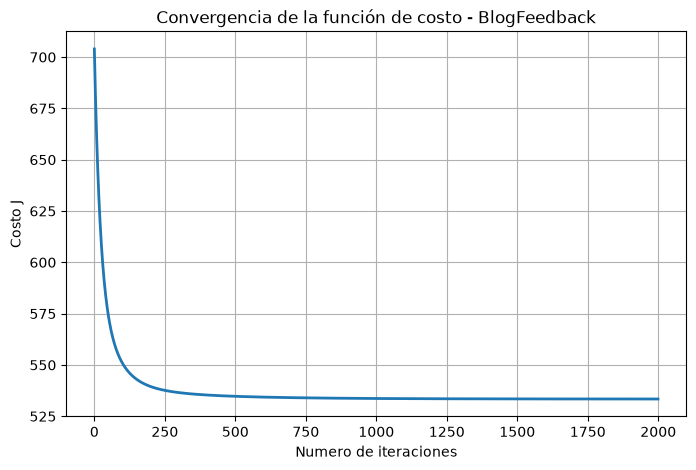

theta calculado por el descenso por el gradiente:
[ 6.72084999e+00  4.75622659e-01  1.60155201e+01  9.63982929e-01
 -1.34484700e-01 -3.31320990e+00  4.34936694e-01 -1.07469927e-01
 -2.07445807e-01  8.35366367e-02  5.37171859e-01  1.06775480e-01
  1.19029399e-01 -1.32371054e-01  1.51815101e-02  2.13437740e-02
  1.29030597e-02  2.18982862e-01 -3.42008631e-01  8.13399966e-01
 -2.21039225e-02]

Costo final J = 533.4235


In [56]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.01
num_iters = 2000

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(X.shape[1])
theta, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.figure(figsize=(8, 5))
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia de la función de costo - BlogFeedback')
pyplot.grid(True)
pyplot.show()

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente:')
print(theta)
print(f'\nCosto final J = {J_history[-1]:.4f}')


In [57]:
# Estimar el número de comentarios para un ejemplo (usando el primer registro normalizado)
# Se normaliza con mu y sigma del entrenamiento
ejemplo = data.iloc[0, :-1].values.astype(float)
ejemplo_norm = (ejemplo - mu) / sigma
X_array = np.concatenate([[1], ejemplo_norm])
pred = np.dot(X_array, theta)

print(f'Predicción para el primer ejemplo: {pred:.2f} comentarios')
print(f'Valor real: {y[0]:.0f} comentarios')


Predicción para el primer ejemplo: 9.39 comentarios
Valor real: 0 comentarios


### 2.3 Ecuacion de la Normal

Una manera de calcular rapidamente el modelo de una regresion lineal es:

$$ \\theta = \\left( X^T X\\right)^{-1} X^T\\vec{y}$$

Utilizando esta formula no requiere que se escale ninguna caracteristica, y se obtendra una solucion exacta con un solo calculo.


In [58]:
# Recargar datos originales (sin normalizar) para la ecuación normal
data2 = pd.read_csv('blogfeedback_20k_20cols.csv')
X2 = data2.iloc[:, :-1].values.astype(float)
y2 = data2.iloc[:, -1].values.astype(float)
m2 = y2.size
X2 = np.concatenate([np.ones((m2, 1)), X2], axis=1)

def normalEqn(X, y):
    theta = np.zeros(X.shape[1])
    # Usamos pinv para mayor estabilidad numérica
    theta = np.dot(np.dot(np.linalg.pinv(np.dot(X.T, X)), X.T), y)
    return theta

# Calcula los parametros con la ecuación de la normal
theta_ne = normalEqn(X2, y2)

print('Theta calculado a partir de la ecuación de la normal:')
print(theta_ne)

# Predicción con ecuación normal (mismo ejemplo)
X_array_ne = np.concatenate([[1], data2.iloc[0, :-1].values.astype(float)])
pred_ne = np.dot(X_array_ne, theta_ne)
print(f'\nPredicción (ecuación normal) para el primer ejemplo: {pred_ne:.2f}')
print(f'Valor real: {y2[0]:.0f}')
print(f'Costo con ecuación normal: {computeCostMulti(X2, y2, theta_ne):.4f}')


Theta calculado a partir de la ecuación de la normal:
[ 6.46251604e+00  2.34319162e-03  2.79733602e-01  7.30421783e-01
 -3.53174687e-01 -1.59658269e-01  1.17066647e-04 -8.63092750e-02
 -1.07360106e-02  2.22396204e-01  1.55944410e+00  3.62155018e-01
  4.15973535e-01 -3.51306728e+00  5.46897914e-02  2.24255322e+00
  6.02678112e-01  4.55180430e-01 -9.25820513e-01  1.90636304e+00
 -4.58150554e-01]

Predicción (ecuación normal) para el primer ejemplo: 9.37
Valor real: 0
Costo con ecuación normal: 533.4126
